<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/Transformer_V/TransformerVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import necessary libraries
import torch
import torchvision
import torchvision.transforms as transform
import torch.utils.data as dataloader
import torch.nn as nn

In [2]:
# transformation for PIL to tensor format
transformation_operation = transform.Compose([transform.ToTensor()])

In [3]:
train_dataset = torchvision.datasets.MNIST(root='./dataset', train=True, download=True, transform=transformation_operation)
val_dataset = torchvision.datasets.MNIST(root='./dataset', train=False, download=True, transform=transformation_operation)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.36MB/s]


In [4]:
# define variable
num_class = 10
batch_size = 64
num_channels = 1
img_size = 28
patch_size = 7
num_patch = (img_size // patch_size) ** 2
embdedding_dim = 64
attention_head = 4
transformer_blocks = 4
learning_rate = 0.001
mlp_hidden_node = 128
epochs= 5


In [5]:
# Define dataset batch
train_loader = dataloader.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = dataloader.DataLoader(val_dataset, batch_size=64, shuffle=True)

In [6]:
# part 1: patch embedding

class PatchEmbedding(nn.Module) :
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embdedding_dim, kernel_size=patch_size, stride=patch_size)

  def forward(self, x):
    # patch_embedding
    x = self.patch_embed(x)  # 64,1,28,28 ===>>  64,64, 4, 4
    x = x.flatten(2)         # 64,64, 4, 4 ====>>> 64,64, 16
    x = x.transpose(1,2)      # 64,64, 16 ===> 64, 16,64

    return x
    # return self.patch_embed(x).flatten(2).transpose(1,2)

In [15]:
# part2 : Transformer encoder
# norm => multihead-attention => norm => MLP
class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_norm1 = nn.LayerNorm(embdedding_dim)
        self.layer_norm2 = nn.LayerNorm(embdedding_dim)

        self.multihead_attention = nn.MultiheadAttention(
            embed_dim=embdedding_dim,
            num_heads=attention_head,
            batch_first=True
        )

        self.mlp = nn.Sequential(
            nn.Linear(embdedding_dim, mlp_hidden_node),
            nn.GELU(),
            nn.Linear(mlp_hidden_node, embdedding_dim)
        )

    def forward(self, x):

        # ===== Multi-Head Attention =====
        residual1 = x

        x = self.layer_norm1(x)

        x = self.multihead_attention(
            x, x, x
        )[0]

        x = x + residual1

        # ===== MLP =====
        residual2 = x

        x = self.layer_norm2(x)

        x = self.mlp(x)

        x = x + residual2

        return x

In [16]:
# part 3 : MLP_Head
class MLP_Head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embdedding_dim)
    self.mlp_head = nn.Linear(embdedding_dim, num_class)

  def forward(self, x):
    x = self.layer_norm1(x)
    x = self.mlp_head(x)

    return x

In [17]:
# part 4 : vision Transformer class

class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1,1,embdedding_dim))
    self.position_embedding = nn.Parameter(torch.randn(1, num_patch+1, embdedding_dim))
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
    self.mlp_head = MLP_Head()


  def forward(self, x):

    x = self.patch_embedding(x)
    B = x.size(0)
    class_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((class_tokens, x), dim = 1)
    x = x + self.position_embedding
    x = self.transformer_blocks(x)
    x = x[:, 0]
    x = self.mlp_head(x)

    return x




In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

criterion = nn.CrossEntropyLoss()

In [19]:
for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct_epoch = 0
    total_epoch = 0

    print(f"\nEpoch {epoch + 1}")

    for batch_idx, (images, label) in enumerate(train_loader):

        # Move data to GPU/CPU
        images = images.to(device)
        label = label.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(images)

        # Calculate loss
        loss = criterion(output, label)

        # Backward pass
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item()

        # Prediction
        preds = output.argmax(dim=1)

        # Number of correct predictions
        correct = (preds == label).sum().item()

        # Batch accuracy
        accuracy = (correct / label.size(0)) * 100.0

        # Epoch statistics
        correct_epoch += correct
        total_epoch += label.size(0)

        # Print every 100 batches
        if batch_idx % 100 == 0:

            print(
                f"Batch {batch_idx + 1:3d} "
                f"Loss = {loss.item():.4f}, "
                f"Accuracy = {accuracy:.2f}%"
            )

    # Epoch accuracy
    epoch_acc = (correct_epoch / total_epoch) * 100

    # Average epoch loss
    epoch_loss = total_loss / len(train_loader)

    print(
        f"==> Epoch {epoch + 1} Summary: "
        f"Loss = {epoch_loss:.4f}, "
        f"Accuracy = {epoch_acc:.2f}%"
    )


Epoch 1
Batch   1 Loss = 2.4540, Accuracy = 7.81%
Batch 101 Loss = 0.5761, Accuracy = 81.25%
Batch 201 Loss = 0.3798, Accuracy = 90.62%
Batch 301 Loss = 0.3915, Accuracy = 90.62%
Batch 401 Loss = 0.3722, Accuracy = 92.19%
Batch 501 Loss = 0.1269, Accuracy = 95.31%
Batch 601 Loss = 0.1438, Accuracy = 95.31%
Batch 701 Loss = 0.3471, Accuracy = 92.19%
Batch 801 Loss = 0.1855, Accuracy = 95.31%
Batch 901 Loss = 0.0591, Accuracy = 96.88%
==> Epoch 1 Summary: Loss = 0.3732, Accuracy = 88.08%

Epoch 2
Batch   1 Loss = 0.1006, Accuracy = 95.31%
Batch 101 Loss = 0.1363, Accuracy = 96.88%
Batch 201 Loss = 0.1063, Accuracy = 98.44%
Batch 301 Loss = 0.0911, Accuracy = 98.44%
Batch 401 Loss = 0.1003, Accuracy = 96.88%
Batch 501 Loss = 0.0916, Accuracy = 96.88%
Batch 601 Loss = 0.1141, Accuracy = 96.88%
Batch 701 Loss = 0.2720, Accuracy = 89.06%
Batch 801 Loss = 0.0750, Accuracy = 96.88%
Batch 901 Loss = 0.1294, Accuracy = 95.31%
==> Epoch 2 Summary: Loss = 0.1226, Accuracy = 96.16%

Epoch 3
Batch 

In [22]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    output = model(images)
    preds = output.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)
test_acc = (correct / total) * 100.0
print(f"\n ===>>> val accuracy : {test_acc : .2f} %")


 ===>>> val accuracy :  97.79 %


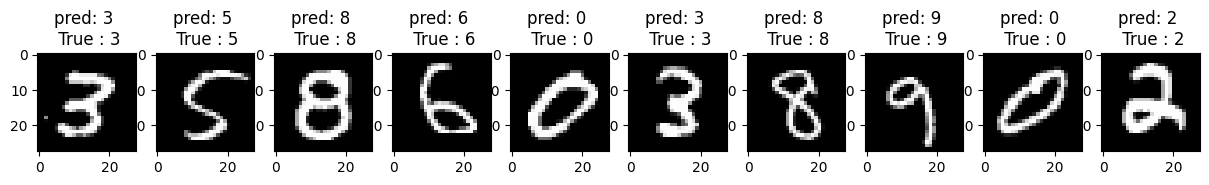

In [26]:
import matplotlib.pyplot as plt


model.eval()

images , labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
  output = model(images)
  preds = output.argmax(dim=1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

plt.figure(figsize = (15, 20))
for i in range(10):

  plt.subplot(5, 10, i+1)
  plt.imshow(images[i].squeeze(), cmap="gray")
  plt.title(f"pred: {preds[i].item()} \n True : {labels[i].item()}")

In [29]:
torch.save(model, "model.pth")

In [32]:
# Save
torch.save(model.state_dict(), "vision_transformer.pth")

# Load
model = VisionTransformer().to(device)
model.load_state_dict(
    torch.load("vision_transformer.pth", map_location=device)
)
model.eval()

VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (patch_embed): Conv2d(1, 64, kernel_size=(7, 7), stride=(7, 7))
  )
  (transformer_blocks): Sequential(
    (0): TransformerEncoder(
      (layer_norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (layer_norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (multihead_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=128, out_features=64, bias=True)
      )
    )
    (1): TransformerEncoder(
      (layer_norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (layer_norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (multihead_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_f

In [20]:
#part: 1

# data_point, label = next(iter(train_loader))

# print("Shape of data Point :", data_point.shape)
# patch_embed = nn.Conv2d(num_channels, embdedding_dim, kernel_size=patch_size, stride=patch_size)

# print(patch_embed(data_point).shape)
# patch_embed_output_flatten = patch_embed(data_point).flatten(2)
# print(patch_embed_output_flatten.shape)
# print(patch_embed_output_flatten.transpose(1,2).shape)

In [21]:

# part 2 : Transformer encoder
# part 3 : MLP_head
# part 4 : vision Transformer class